# Face Recognition using CNN with Labeled Faces in the Wild (LFW) Dataset

## Objective
The objective of this project is to develop a Convolutional Neural Network (CNN) model that can recognize human faces using the Labeled Faces in the Wild (LFW) dataset. The model learns facial features from images and predicts the identity of a person from unseen face images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.5)

In [3]:
# Load images and labels
X = lfw.images
y = lfw.target
target_names = lfw.target_names

print("Image Shape:", X.shape)
print("Number of Images:", len(X))
print("Number of Classes:", len(target_names))
print("Class Names:")
print(target_names)

Image Shape: (1560, 62, 47)
Number of Images: 1560
Number of Classes: 12
Class Names:
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


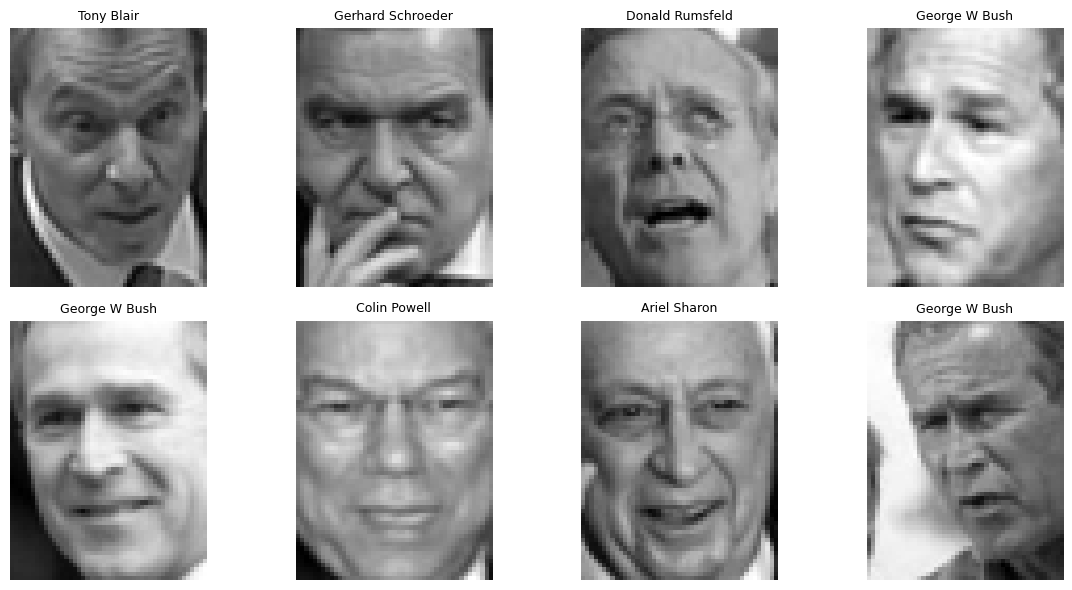

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i], cmap='gray')
    plt.title(target_names[y[i]], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Normalize pixel values (0-255 → 0-1)
X = X.astype("float32") / 255.0

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 0.003921569


In [6]:
# Add channel dimension for CNN
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

print("New Shape:", X.shape)

New Shape: (1560, 62, 47, 1)


In [7]:
from tensorflow.keras.utils import to_categorical

num_classes = len(target_names)

y = to_categorical(y, num_classes)

print("Label Shape:", y.shape)

Label Shape: (1560, 12)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (1248, 62, 47, 1)
Testing Images: (312, 62, 47, 1)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(62, 47, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 45, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,147,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,167,372 (4.45 MB)

 Trainable params: 1,167,372 (4.45 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.3387 - loss: 2.2436 - val_accuracy: 0.3120 - val_loss: 2.1741
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.3467 - loss: 2.1742 - val_accuracy: 0.3120 - val_loss: 2.1720
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.3467 - loss: 2.1722 - val_accuracy: 0.3120 - val_loss: 2.1633
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3467 - loss: 2.1627 - val_accuracy: 0.3120 - val_loss: 2.1643
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3477 - loss: 2.1662 - val_accuracy: 0.3120 - val_loss: 2.1861
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.3467 - loss: 2.1683 - val_accuracy: 0.3120 - val_loss: 2.1648
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3467 - loss: 2.1649 - val_accuracy: 0.3120 - val_loss: 2.1632
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3467 - loss: 2.1579 - val_accuracy: 0.3120 - v

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3397 - loss: 2.1581
Test Loss: 2.158073902130127
Test Accuracy: 0.33974358439445496


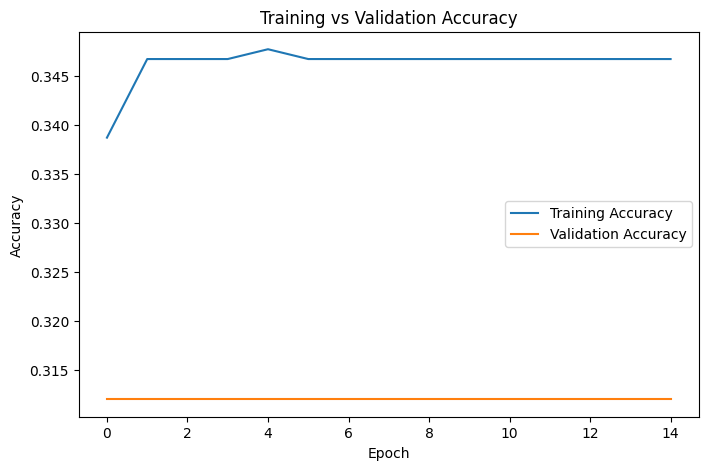

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

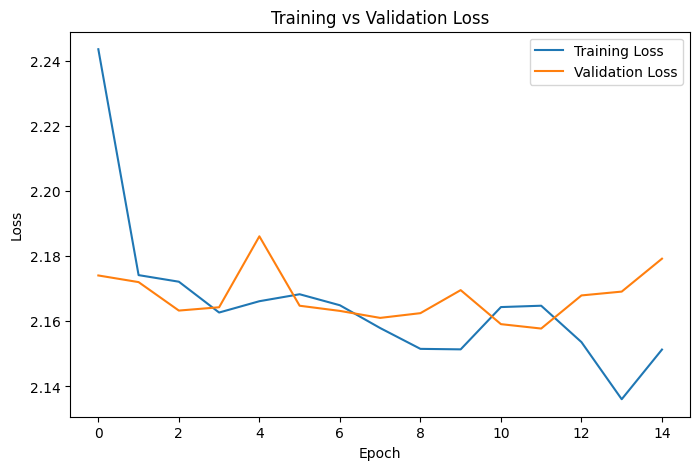

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)
true_labels = y_test.argmax(axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


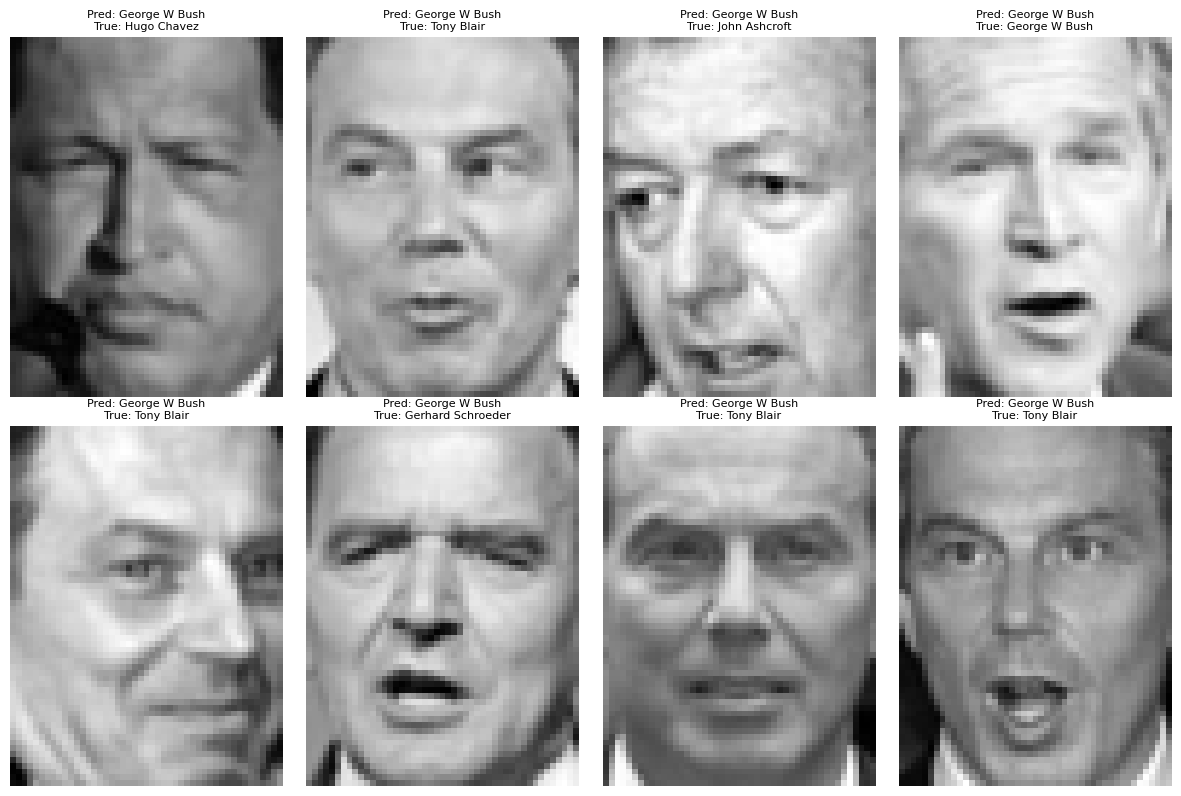

In [16]:
plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    plt.imshow(X_test[i].reshape(62,47), cmap='gray')

    plt.title(
        f"Pred: {target_names[predicted_labels[i]]}\nTrue: {target_names[true_labels[i]]}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=target_names
))

                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       0.34      1.00      0.51       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
   Jacques Chirac       0.00      0.00      0.00        10
    Jean Chretien       0.00      0.00      0.00        11
    John Ashcroft       0.00      0.00      0.00        11
Junichiro Koizumi       0.00      0.00      0.00        12
  Serena Williams       0.00      0.00      0.00        10
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.34       312
        macro avg       0.03      0.08      0.04       312
     weighted avg       0.12      0.34      0.17       312



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


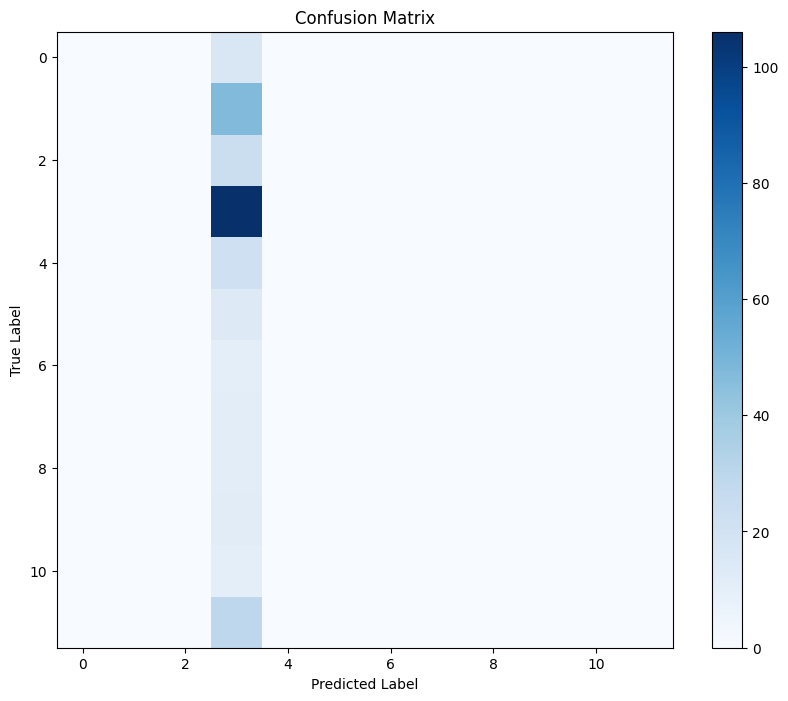

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

In [19]:
model.save("face_recognition_cnn_lfw.keras")

print("Model saved successfully!")

Model saved successfully!
